hipotesis 
Los pacientes con un peor perfil cardiovascular y metabólico tendrán mayor probabilidad de desarrollar enfermedad coronaria en los próximos 10 años

In [1]:
#librerias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
#carga de dataset 

df = pd.read_csv("framingham.csv")

In [ ]:
#vista general de dataset
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [8]:
df.shape

(4240, 16)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [16]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

In [10]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Se realiza una inspección inicial del dataset para conocer su estructura, tipos de datos y calidad general.

In [13]:
#nulos 
df.isnull().sum()


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

vemos que ya en el word de estudio de framingham nos dice que hay nulos pero se tendria que ver que tipo de nulos son y si son nulos que se pueden eliminar o son nulos que no se deberain de mirar , se deberia de imputar con la mediana para reducir el efecto de posibles valores extremos,  en los que tienen nulos como :BMI, glucose , totchol ... tambien es verdad que hay pueden haber nulos donde por ejemplo education puede tener nulos ya que hay gente que no tiene education o no es currentsmoker

In [ ]:
#duplicados
df.duplicated().sum()

#no hay duplicados

np.int64(0)

In [24]:
#separar variables numericas y categoricas 

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


In [26]:
num_cols

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

In [27]:
cat_cols

Index([], dtype='str')

se puede ver que casi todos son numericos , ya que  muchas variables son     categóricas/binarias están guardadas como números.pero intentando separarlo manualmente se podria ver que en numeroas :age, ciges , diabp, bmi , heartrate,glucose, y en caretegoricas o binarias estaria las demas que serian : male , education , currentsmoker...

En el siguiente codigo separo los datos , veo la variable objetivo TenYearCHD y se analiza su distribución.

In [ ]:
#para separar de manera limpia 
#IA
target = "TenYearCHD"

print(df[target].value_counts(normalize=True))

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_like = ["male", "education", "currentSmoker", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes", "TenYearCHD"]

num_cols = [col for col in num_cols if col not in cat_like]
cat_cols = cat_like

print("Numericas:", num_cols)
print("Categoricas/binarias:", cat_cols)

TenYearCHD
0    0.848113
1    0.151887
Name: proportion, dtype: float64
Numericas: ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
Categoricas/binarias: ['male', 'education', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


se puede ver que la variable objetivo hay un desbalance ya que 0= 0,84 y 1= 0,15 eso significa que el 84% no dsarollan enfermedades en los 10 años y 15% si desarollan enfermedades en los 10 años .

Las variables numericas son variables reales de numeros que si tienen sentido mirar y los otros variables si es verdad que son numericas tambien,  pero no son medidas continuas, sino que son categorías .Sobre todo en la parte de estudios que son numeros de 1 - 4 que se supone que son los niveles de estudio , tambien se puede ver como estan divididos en grupoa en el word de framingham

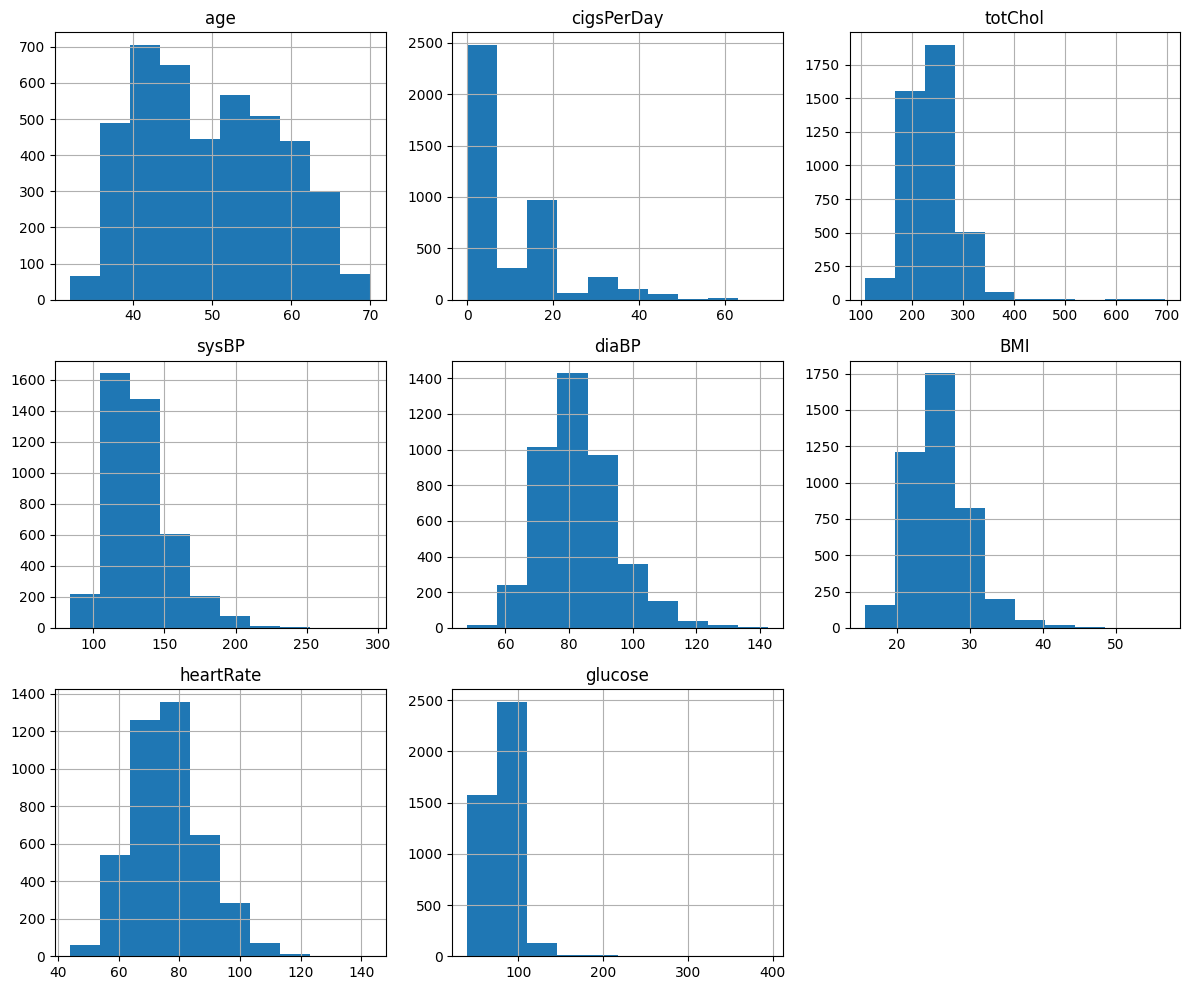

In [35]:
#histogramas de los numericos
df[num_cols].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


Vemos que en año donde se concentra mas las edades de 35/40 - 60/65.
En la de cisperday vemos que no hay tanta gente que fume mas de 20 cigarros , se puede ver que la mayoria no fuma mas de 5-10 , pero vemos una leve subida entre los 10-20 cigarros, osea que hay dos grupos en los que no se fuma tanto y otros que fuman mucho , vemos valores de gente incluso de mas de 30_40 cigarros 
En totchol se ve que se concentra etre 150-290 , igual se ve gente con colesterol bastante alto aun que haya poca gente 
En sysbp se conentra en 110-140 y se puede ver que hay un grupo de mayor sysbp , a la derecha
En diabp se ve una concentracion en los valores medios.
En bmi vemos que hay una concentracion en la de 20-30 pero se ve un grupo de la derecha donde tienen el bmi bastante alto 
En hearrate se puede ver que hay una concentracion en los valores medios , aun asi hay un grupo miniritario apartire de mas de 100 rate


En resumen la mayoria de estos histogramas tienen una concentracion en la parte indermedia pero siempre a la parte de la derecha siempre suele un grupo minoritario donde tiene el indice muy alto , entonces en algunos vemos que hay sesgo a la derecha osea que la mayoría de valores están en la parte baja-media, pero hay algunos valores muy altos , pero en age, diaBP y heartRate se concentran mas en los valores medios 


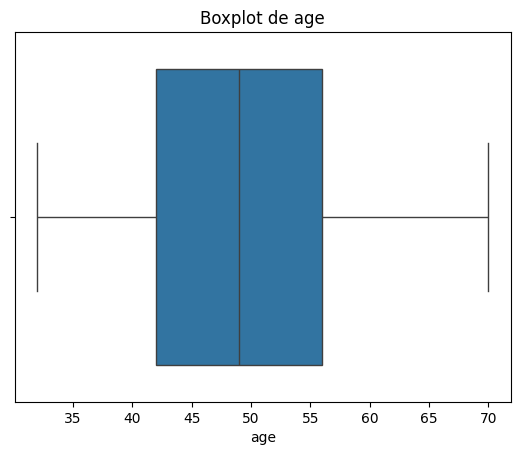

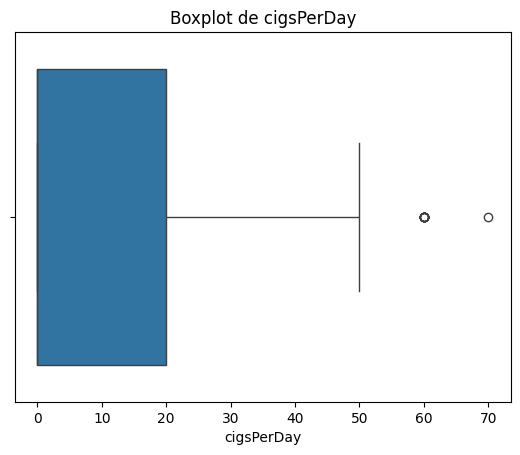

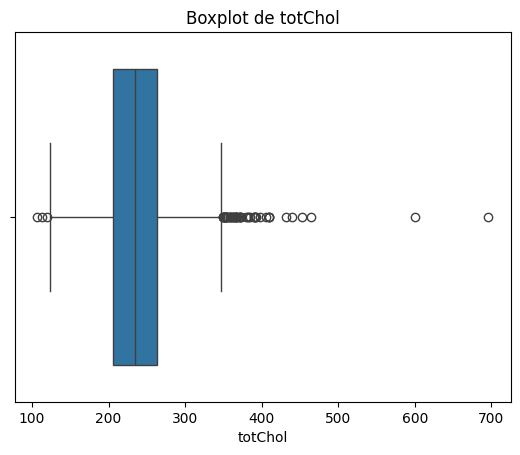

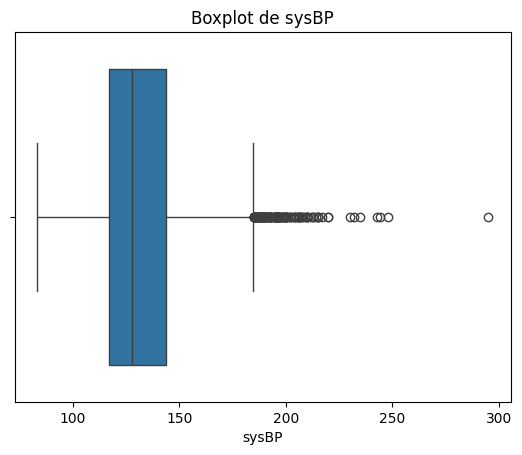

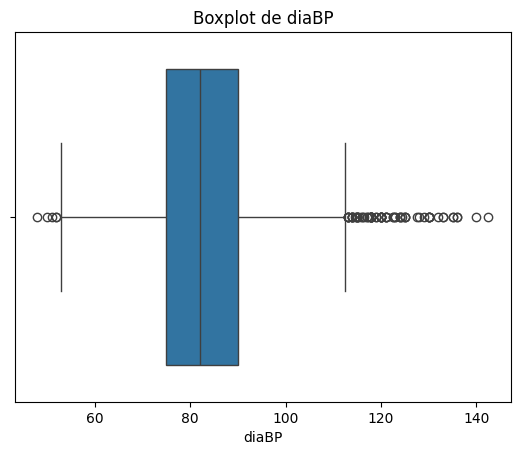

In [34]:
#boxplot de numerico 
for col in num_cols[:5]:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


En la parte de edad no se ve nada raro simplenete hay una concentracion en la edad en la parte intermadia 
En la de cigs por dia y totchol se puede ver que en el de los cigaros hay mucha gente que fuma poco o casi nada pero leuego hay un gruupo donde fuman mucho mas que la media , al igual que en totchol vemos una concentracion donde 200 , pero luego hay gente con el chol super alto y incluso una minoria de chol bajo 
En la de sysbp y en diabp pasa algo parecido a totchol y cigspordia , donde hay una clara concentracion en medio pero luego hay gente con signos muy elevados y algunos pocos muy bajos 
Menos en el de edad donde se puede ver que la mayoria estan en la media 


In [36]:
for col in cat_cols[:5]:
    print("\n", col)
    print(df[col].value_counts().head())



 male
male
0    2420
1    1820
Name: count, dtype: int64

 education
education
1.0    1825
2.0    1253
3.0     689
4.0     473
Name: count, dtype: int64

 currentSmoker
currentSmoker
0    2145
1    2095
Name: count, dtype: int64

 BPMeds
BPMeds
0.0    4063
1.0     124
Name: count, dtype: int64

 prevalentStroke
prevalentStroke
0    4215
1      25
Name: count, dtype: int64


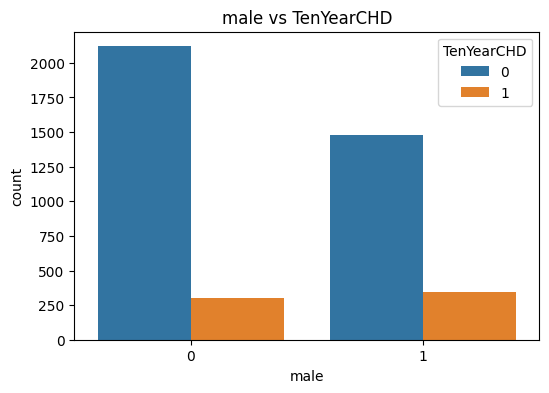

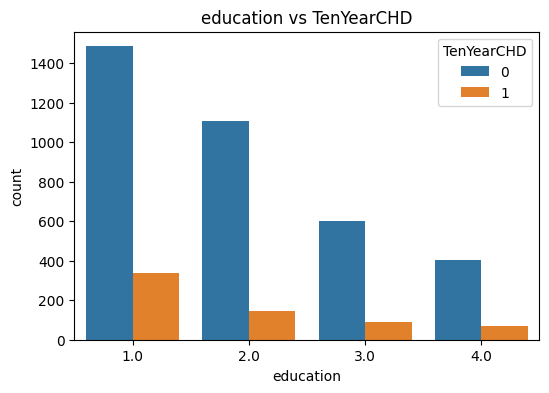

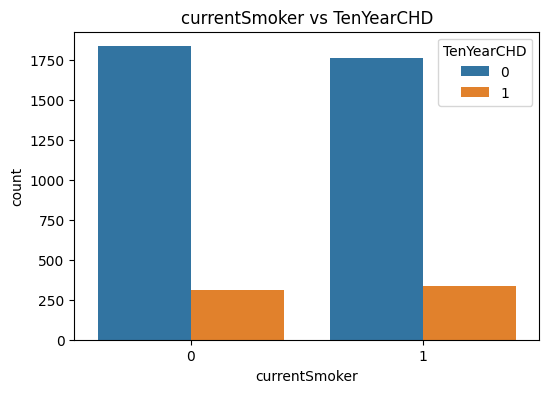

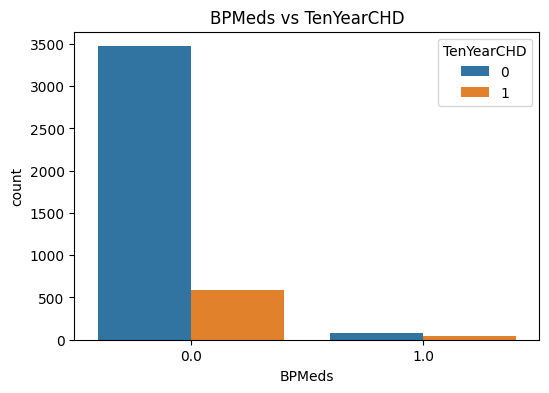

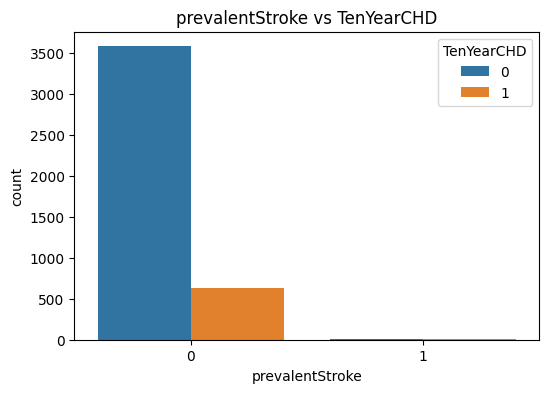

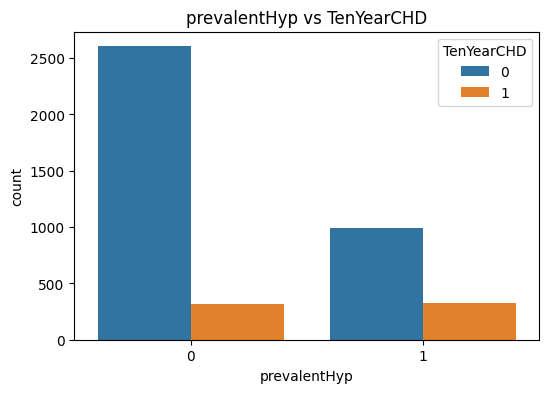

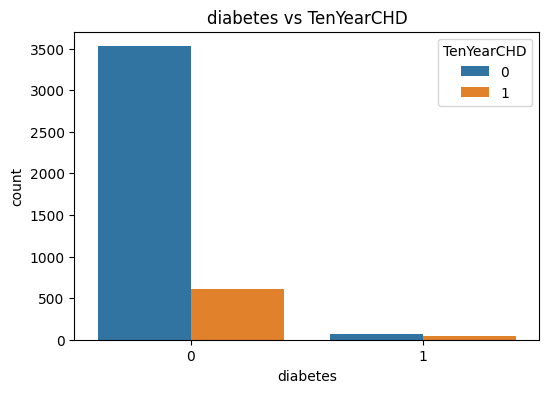

In [ ]:
#categoricas vs target
for col in cat_cols_no_target:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], hue=df["TenYearCHD"])
    plt.title(f"{col} vs TenYearCHD")
    plt.show()

se puede observar que en la tabla de male hay mas mujeres que hombres y en temma de enfermar es parejo la verda asi que no tiene mucha relacion , sin embargo en la parte de education se ve que hay una bajada de gente a medida que tiene mas estudios o mayor estudio y tambien se puede ver que va bajando un poco el porcentaje de la gente que enferma pero es verdad que en los estudios 3 y 4 en los enfermados son bastante parecidos , tambien se puede ver en los fumadores actuales no tiene nada que ver si sigues fumando o no , no cambia nada si sigues fumando o no ya que se ve que la gente que enferma es bastante parecida , por lo tanto creo que no hay que fijarse en la gente si sigue fumando actualmente o no si no que cuantos se fuma al dia , en bpmeds , prevanlestroke y diabetes , se ve que la gente que no es bastante mas alta pero se ve que la gente q si en tema de que si estan enfermos tienen que ver ya que es verdad que es menos gente a la que si pero es casi la mitad de enfermos en estas variables y en prevalnthyp se ve que hay mas gente que no a la q si pero es bastante parecido en tema de gente enfermada ya que hay mas gente enferma en si que no por lo tanto se ve que tiene bastante que ver el prevalntrhype con la psoibilidad de enfermas al al igual que en bpmdes, prevanlestrok y diabets

In [ ]:
#para ver mejor los valores
pd.crosstab(df["prevalentStroke"], df["TenYearCHD"], normalize="index")

TenYearCHD,0,1
prevalentStroke,,
0,0.849822,0.150178
1,0.560000,0.440000


In [44]:
pd.crosstab(df["BPMeds"], df["TenYearCHD"], normalize="index")

TenYearCHD,0,1
BPMeds,,
0.0,0.854295,0.145705
1.0,0.669355,0.330645


In [45]:
pd.crosstab(df["diabetes"], df["TenYearCHD"], normalize="index")

TenYearCHD,0,1
diabetes,,
0,0.853788,0.146212
1,0.633028,0.366972


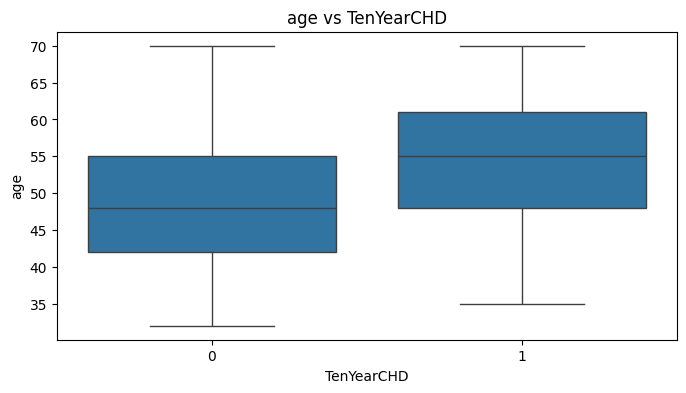

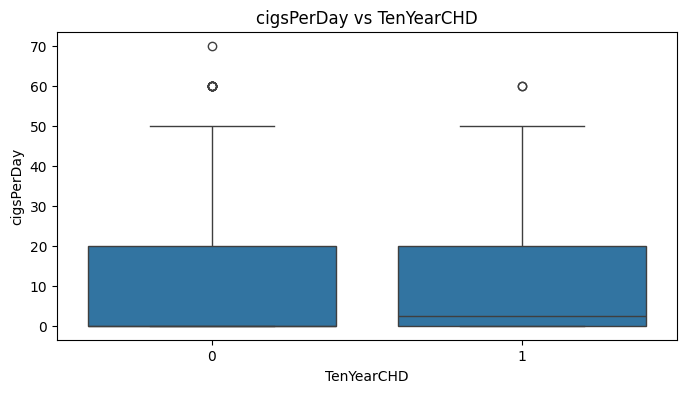

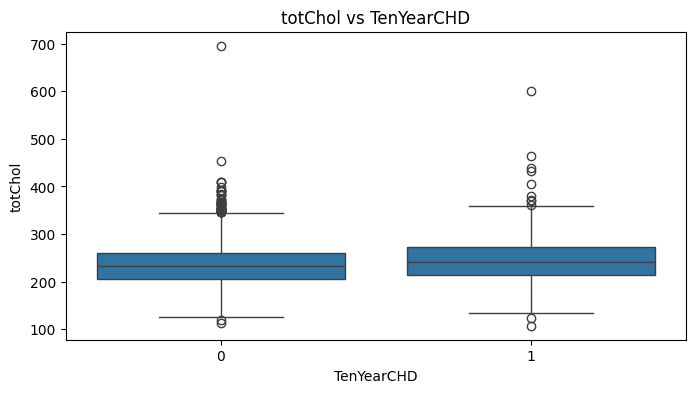

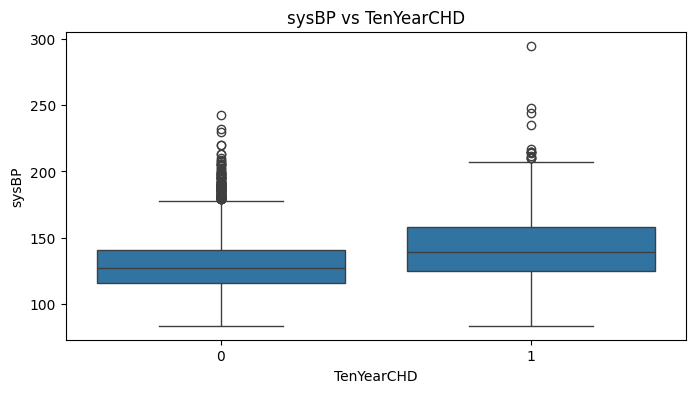

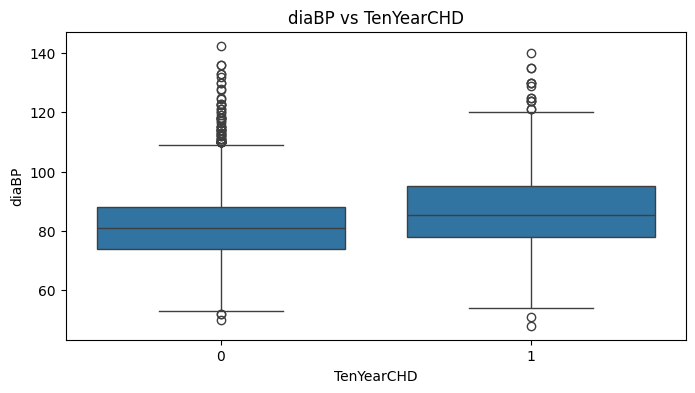

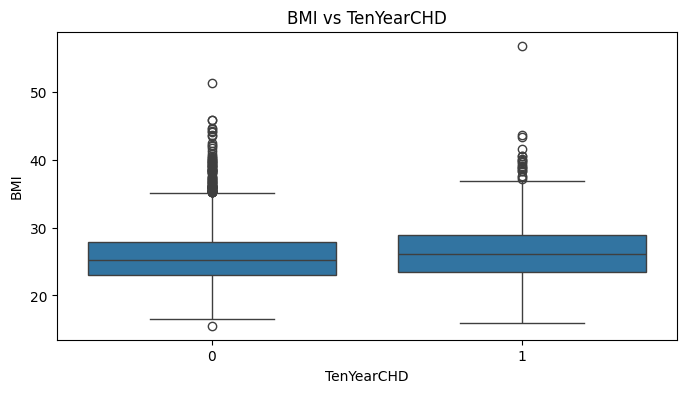

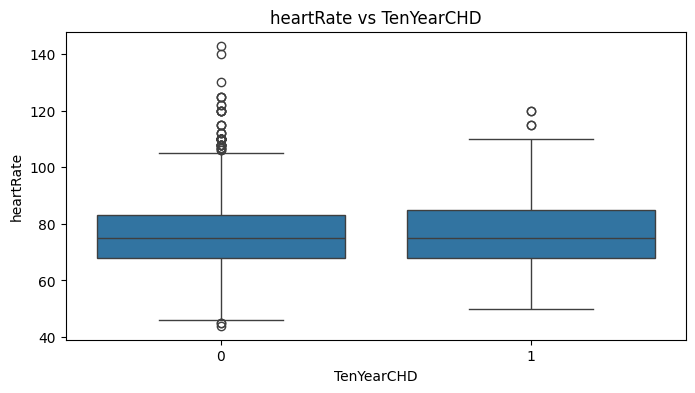

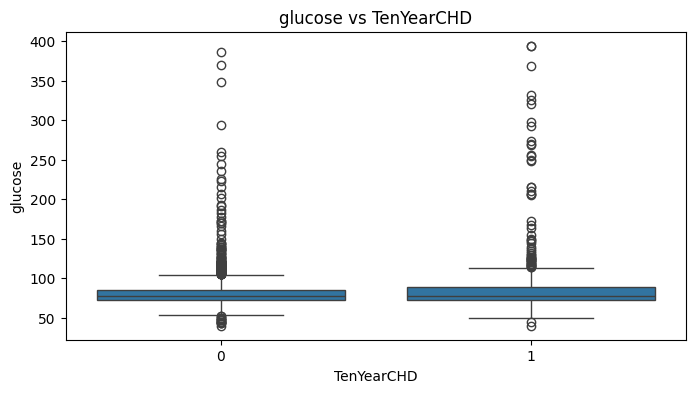

In [46]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df["TenYearCHD"], y=df[col])
    plt.title(f"{col} vs TenYearCHD")
    plt.show()

se puede ver que en alos la gente que suele se run poco mas mayor es mas probable que enfermen , los pacientes que desarrollan enfermedad coronaria parecen fumar un poco más, pero la diferencia no es exageradamente clara en el boxplot , en las demas tanmbien se puede ver que no hay mayor diferencia si es uno o otro para desarollar enfermedad , esta claro que la edad se ve que la gente un poco mas mayor hay mas poibilidad de enfermar en los 10 años 

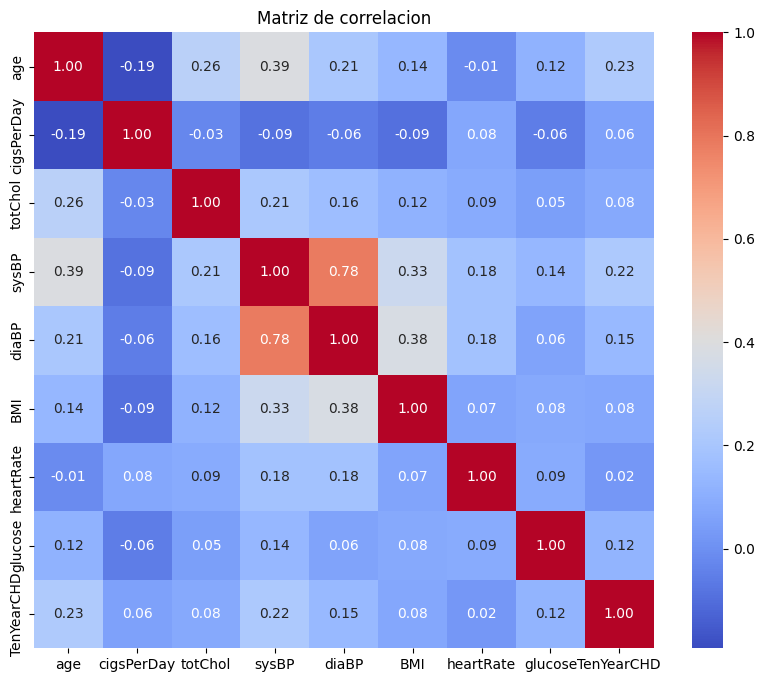

In [47]:
corr = df[num_cols + ["TenYearCHD"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlacion")
plt.show()

se puede ver la relacion lineal entre las variables numericas y la variable objetivo TenYearCHD. Las correlaciones mas altas con la target corresponden a age y sysBP, seguidas de diaBP y glucose, lo que sugiere que estas variables podrían tener mayor relación con el riesgo de enfermedad coronaria a 10 años. ademas, destaca la fuerte correlación entre sysBP y diaBP, lo que indica que ambas medidas de presión arterial están muy relacionadas entre sí.como la variable objetivo es binaria y las correlaciones observadas no son muy elevadas, conviene mejorar esta información con otros análisis  y comparaciones por grupos.

Que hacder con outliers

Se ve que los valores extremos en variables como cigsperday, totchol, sysbp, diabp y glucose. No se eliminan automáticamente ya que podrían ser casos reales y clínicamente relevantes. En el sivguiente paso se  podría valorarse su revisión, transformación o winsorización .

CONTRASTE DE HIPOTESIS 


al inicio se planatea que variables edad , tabaquismo , presion arterial , coresterol , glucosa , imc y diabetes podrian estar relacionado con enfermar en 10 años , pero despues del eda se ve que es muy importante la edad , la presion arterial yb la glucosa mientras que otras como cigaros porn dia o bmi muetras relacio menos clara 

(no me da a hacer la conclusion )